### **Mushroom dataset (classification) — Optimization Plan**
#### Here is the list how optimization tools will be used:
- Distribution and imbalance management.<br> Sampling: SMOTE (Oversampling) I will use it on  classification mushroonm dataset and (QuantileTransformer and RANSAC) on regression dataset.<br>Data synthetization: 
- Noise management: MAD - regression housing dataset;
- Overlap management: TomekLinks - classification mushroonm dataset;
- Outlier management: IQR + Isolation Forest - regression housing dataset;

#### In this notebook I will evaluate only optimization tools that will be applied on classification mushroom dataset.

### **Distribution and imbalance management**
#### **Sampling: SMOTE (Oversampling)**
#### I will use mushroom dataset that has removed variables that have no effect on target variables. Many kept variables are encoded. (Encoding and removal was performed here - Exercise_project_1\Classification_dataset\dataset_analysis_code.ipynb). I will choose variables that have importance for target variable based on SHAP and the variables/variable that are numeeric ('stem-width' and 'stem-height',  that have high cardinality) or were transformed using Label Encoding because One-hot encoded variables does not work well with SMOTE as they are sparse one-hot vectors (According to Chatgpt).
- SMOTE first try, it didn't work, beacuse numeric variables have too high cardinality. Implementation is here: Exercise_project_2\Classification_dataset\smote_classification_oversampling_first_try.ipynb<br>
- SMOTE second try, this one worked. I generated syntetic values for "does-bruise-or-bleed" variable. Only this variable has binary, LabelEncoded values and has impact on target variable. <br> Implementation is here: Exercise_project_2\Classification_dataset\smote_classification_oversampling_second_try.ipynb<br>Results:<br>
- before applying SMOTE:<br>
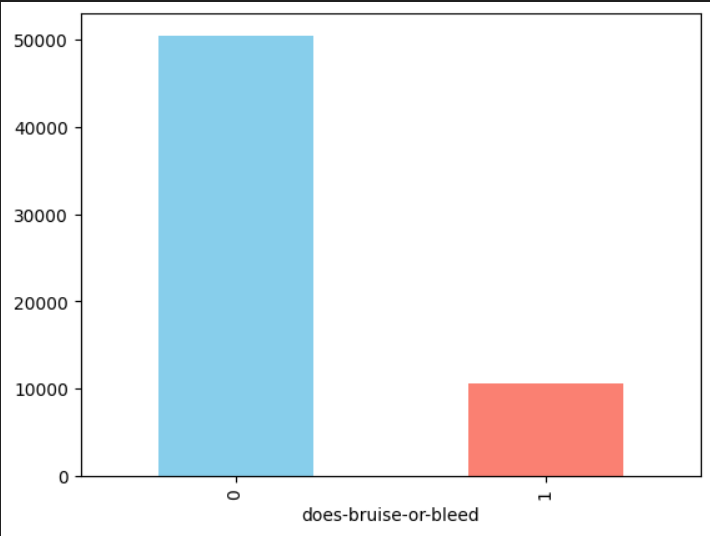<br>
- after applying SMOTE:<br>
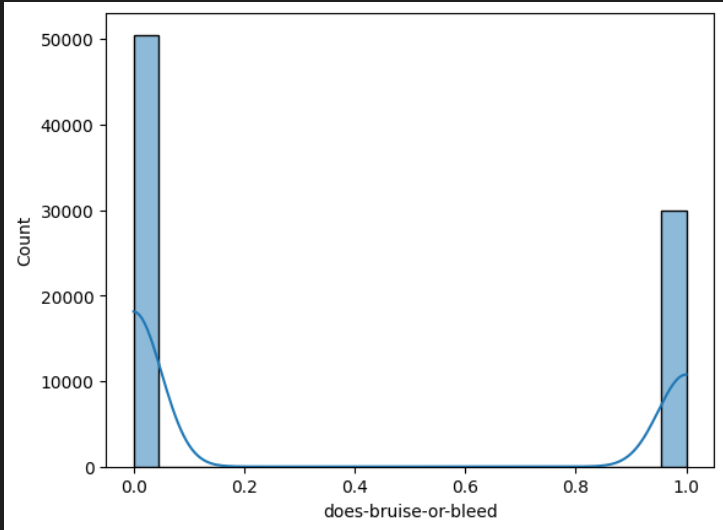<br>
#### We can see that now variable 'does-bruise-or-bleed' is not imbalanced, Smote creates synthetic samples based on target variable and on numeric varibles. 


### **Overlap management: TomekLinks**
#### TomekLinks, scatterplot with hue- "class"<br> Based on SHAP result  I will check overlapping between "stem-height" and "gill-spacing_d" variables:<br>On scatterplot we can see that within each band, both classes (0 and 1) appear at similar stem heights also there is strong mixing for low to mid stem heights. This visually shows local class overlap.
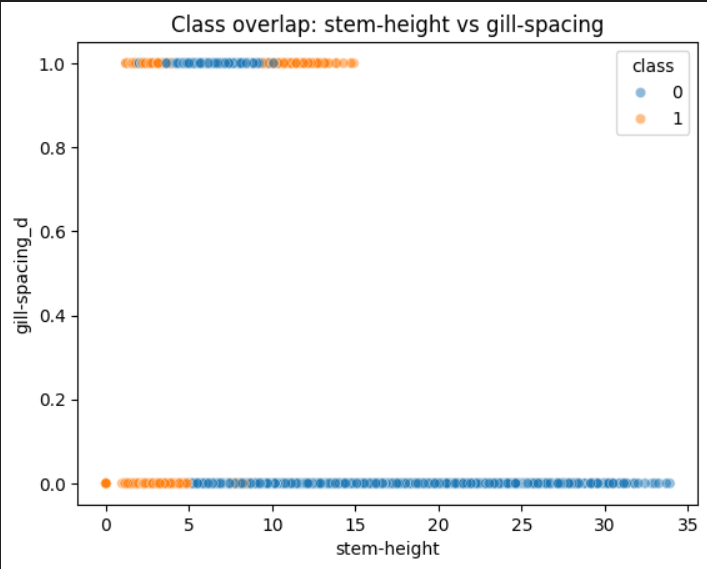<br>
#### On the box-plot below we can see many outliers, especially for stem-height > 13. Also we can see that many mushrooms share similar stem heights but have opposite class labels. This plot shows us possible noise and overlap.
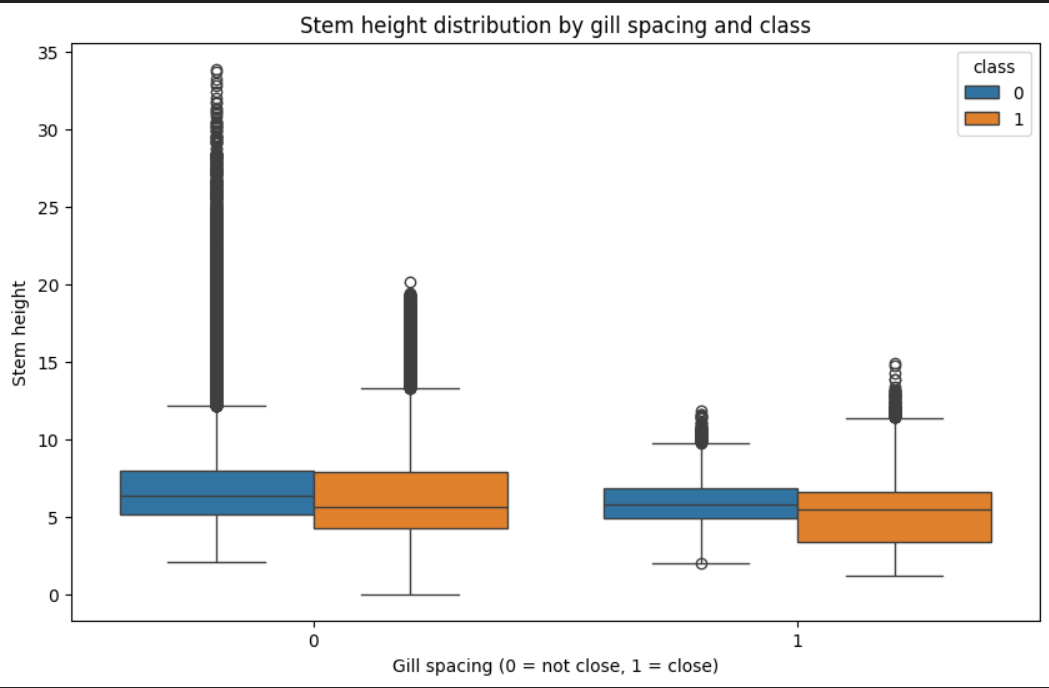<br>
#### TomekLinks was applied to the one-hot encoded varialbe - "gill-spacing_d" to reduce potential class overlap(that was showen on plot above). However, the method did not remove any samples. This indicates that although overlap is visible, variable are very well seperated in this dataset. Maybe TomekLinks didn't work because I inspected encoded variable tthat created strong categorical separation.<br>Code ref:Exercise_project_2\Classification_dataset\tomekLinks_classif.ipynb

### **Final Evaluation of the Optimized Datasets**
- How close did we get to an “optimal” distribution?
#### **Regression dataset**:<br> Firstly, I used QuantileTransformer that normalised distribution but using this method i loose all the original values of variables that had skewed distribution, which is not good. I think that iqr method made job better, althought for some varialbes like "distance_to_nearest_city" or "housing_median_age"it didn't remove much outliers or didn't see the outliers. Though this way it still reflects some natural skewness expected in real-world data. <br>**Classification dataset**:<br>I tested TomeksLinks to make support variable gill-spacing_d distribution closer to normal but it didn't work. Maybe because this variable is hot-encoded and it separates from other variables. SMOTE method works, I generated syntetic values for "does-bruise-or-bleed" variable. I worked on this variable because it has binary, LabelEncoded values and has impact on target variable.
- Which methods were most effective?
#### **Regression dataset**:<br> I would say that IQR-based outlier handling was the most effective. This method reduced extreme outliers. Actually, iutlier handling was more effective than aggressive QuantileTransformer, as it improved distribution quality without distorting the data.<br>**Classification dataset**:<br> Most effective methods was SMOTE that increased minority class representation without simply duplicating samples.
- Do the optimized datasets still represent real-life phenomena well?
#### **Regression dataset**:<br> It was challenging for me to regenerate and manage a new version of the housing dataset after each applied method. Because when I was implementing different meethods I didn't think about saving a result dataset. But I did that in iqr method and I can say that the optimized regression dataset is less noisy but still realistic. New dataset still has multlicollinearity for housing_median_age and total_rooms variables. THe amount of rows decreased from 20640 to 17680 which is not significant. Correlations with target value stayed the same. Mean value didn't change much for all the variables.
**Classification dataset**:<br>In this project I didn't do much optimization for this dataset. I have only successfully applied Smote method,  Tomeklinks didn't show any result. For classification dataset i did a lot in First Project where I found out which varibales are importand by using Shap mechod. I have reduced number of variables by choosing only important ones and encoding them. Anyway I still have too many variables and would appritiate your advise what to do with so many categorical variables.